In [33]:
import json
import math
import pandas as pd
import matplotlib.pyplot as plt


def load_data():
    """
    Load the Munich GeoJSON boundary data and MVV real-time data.

    Returns
    -------
    munich_map : dict
        Munich boundary data loaded from the GeoJSON file.

    delay_df : pandas.DataFrame
        MVV real-time data loaded from the Parquet file.
    """

    with open("../data/munich.geojson", "r") as f:
        munich_map = json.load(f)

    delay_df = pd.read_parquet("../data/mvv_realtime.parquet")

    return munich_map, delay_df

munich_map, delay_df = load_data()

In [34]:
def wgs84_to_utm32(latitude, longitude):
    """
    Convert WGS84 geographic coordinates to UTM Zone 32N.

    Parameters
    ----------
    latitude : float
        Latitude in decimal degrees.

    longitude : float
        Longitude in decimal degrees.

    Returns
    -------
    easting : float
        UTM easting coordinate in meters.

    northing : float
        UTM northing coordinate in meters.
    """

    earth_semi_major_axis = 6378137.0
    eccentricity_squared = 0.00669437999014
    scale_factor = 0.9996

    latitude_radians = math.radians(latitude)
    longitude_radians = math.radians(longitude)

    central_meridian_radians = math.radians(9.0)

    second_eccentricity_squared = (
        eccentricity_squared
        / (1 - eccentricity_squared)
    )

    radius_of_curvature = (
        earth_semi_major_axis
        / math.sqrt(
            1
            - eccentricity_squared
            * math.sin(latitude_radians) ** 2
        )
    )

    tangent_squared = math.tan(latitude_radians) ** 2

    cosine_term = (
        second_eccentricity_squared
        * math.cos(latitude_radians) ** 2
    )

    longitude_difference = (
        math.cos(latitude_radians)
        * (
            longitude_radians
            - central_meridian_radians
        )
    )

    meridional_arc = earth_semi_major_axis * (
        (
            1
            - eccentricity_squared / 4
            - 3 * eccentricity_squared**2 / 64
            - 5 * eccentricity_squared**3 / 256
        )
        * latitude_radians

        - (
            3 * eccentricity_squared / 8
            + 3 * eccentricity_squared**2 / 32
            + 45 * eccentricity_squared**3 / 1024
        )
        * math.sin(2 * latitude_radians)

        + (
            15 * eccentricity_squared**2 / 256
            + 45 * eccentricity_squared**3 / 1024
        )
        * math.sin(4 * latitude_radians)

        - (
            35 * eccentricity_squared**3 / 3072
        )
        * math.sin(6 * latitude_radians)
    )

    easting = (
        scale_factor
        * radius_of_curvature
        * (
            longitude_difference
            + (
                1
                - tangent_squared
                + cosine_term
            )
            * longitude_difference**3
            / 6
            + (
                5
                - 18 * tangent_squared
                + tangent_squared**2
                + 72 * cosine_term
                - 58 * second_eccentricity_squared
            )
            * longitude_difference**5
            / 120
        )
        + 500000.0
    )

    northing = scale_factor * (
        meridional_arc
        + radius_of_curvature
        * math.tan(latitude_radians)
        * (
            longitude_difference**2 / 2

            + (
                5
                - tangent_squared
                + 9 * cosine_term
                + 4 * cosine_term**2
            )
            * longitude_difference**4
            / 24

            + (
                61
                - 58 * tangent_squared
                + tangent_squared**2
                + 600 * cosine_term
                - 330 * second_eccentricity_squared
            )
            * longitude_difference**6
            / 720
        )
    )

    return easting, northing

In [35]:
def point_is_inside_polygon(point_x, point_y, polygon_coordinates):
    """
    Determine whether a point lies inside a polygon.

    Parameters
    ----------
    point_x : float
        X-coordinate of the point.

    point_y : float
        Y-coordinate of the point.

    polygon_coordinates : list of tuple
        Polygon vertices represented as (x, y) coordinate pairs.

    Returns
    -------
    bool
        True if the point lies inside the polygon, otherwise False.
    """

    point_is_inside = False

    number_of_vertices = len(polygon_coordinates)

    for vertex_index in range(number_of_vertices):

        current_vertex_x, current_vertex_y = (
            polygon_coordinates[vertex_index]
        )

        next_vertex_x, next_vertex_y = (
            polygon_coordinates[
                (vertex_index + 1) % number_of_vertices
            ]
        )

        if (current_vertex_y > point_y) != (
            next_vertex_y > point_y
        ):

            x_intersection = (
                (next_vertex_x - current_vertex_x)
                * (point_y - current_vertex_y)
                / (next_vertex_y - current_vertex_y)
                + current_vertex_x
            )

            if point_x < x_intersection:
                point_is_inside = not point_is_inside

    return point_is_inside

In [36]:
def point_is_inside_munich(
    point_x,
    point_y,
    munich_geojson
):
    """
    Determine whether a point lies within the boundaries of Munich.

    Parameters
    ----------
    point_x : float
        X-coordinate of the point in the coordinate system
        used by the GeoJSON data.

    point_y : float
        Y-coordinate of the point in the coordinate system
        used by the GeoJSON data.

    munich_geojson : dict
        GeoJSON data containing the boundaries of Munich.

    Returns
    -------
    bool
        True if the point lies within Munich, otherwise False.
    """

    for geojson_feature in munich_geojson["features"]:

        geometry = geojson_feature["geometry"]
        geometry_type = geometry["type"]

        if geometry_type == "Polygon":

            polygon_rings = geometry["coordinates"]

            for polygon_ring in polygon_rings:

                if point_is_inside_polygon(
                    point_x,
                    point_y,
                    polygon_ring
                ):
                    return True

        elif geometry_type == "MultiPolygon":

            polygons = geometry["coordinates"]

            for polygon in polygons:

                polygon_rings = polygon

                for polygon_ring in polygon_rings:

                    if is_point_inside_polygon(
                        point_x,
                        point_y,
                        polygon_ring
                    ):
                        return True

    return False

In [37]:
def calculate_average_station_delay(delay_df):
    """
    Calculate the average departure delay for each station.

    Parameters
    ----------
    delay_df : pandas.DataFrame
        DataFrame containing departure delay data.
        The DataFrame must contain the columns
        ``stop_id``, ``stop_name`` and ``departure_delay``.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the average departure delay
        per station in seconds and minutes. Negative delays
        are clipped to zero minutes.
    """

    station_delay = (
        delay_df
        .dropna(subset=["departure_delay"])
        .groupby(
            ["stop_id", "stop_name"],
            as_index=False
        )["departure_delay"]
        .mean()
    )

    station_delay["delay_minutes"] = (
        station_delay["departure_delay"] / 60
    )

    station_delay["delay_minutes"] = (
        station_delay["delay_minutes"]
        .clip(lower=0)
    )

    return station_delay

station_delay = calculate_average_station_delay(delay_df)


In [38]:
def load_stop_coordinates(stops_path="../data/stops.txt"):
    """
    Load stop information and coordinates from a GTFS stops file.

    Parameters
    ----------
    stops_path : str
        Path to the GTFS stops.txt file.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing stop IDs, stop names, latitudes,
        and longitudes.
    """

    stops_df = pd.read_csv(stops_path)

    stops_df["stop_id"] = (
        stops_df["stop_id"]
        .astype(str)
    )

    stops_df = stops_df[
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon"
        ]
    ]

    return stops_df

stops_df = load_stop_coordinates()

In [39]:
def merge_station_delays_with_coordinates(
    station_delay_df,
    stops_df
):
    """
    Merge station delay data with stop coordinates.

    Parameters
    ----------
    station_delay_df : pandas.DataFrame
        DataFrame containing average delay information per station.
        Must contain ``stop_id`` and ``stop_name`` columns.

    stops_df : pandas.DataFrame
        DataFrame containing stop coordinates.
        Must contain ``stop_id``, ``stop_name``, ``stop_lat``,
        and ``stop_lon`` columns.

    Returns
    -------
    pandas.DataFrame
        Merged DataFrame containing station delays and coordinates.
        Stations without valid latitude or longitude values are removed.
    """

    station_delay_df = station_delay_df.merge(
        stops_df,
        on=["stop_id", "stop_name"],
        how="left"
    )

    station_delay_df = station_delay_df.dropna(
        subset=[
            "stop_lat",
            "stop_lon"
        ]
    )

    return station_delay_df

station_delay = merge_station_delays_with_coordinates(
    station_delay,
    stops_df
)

In [40]:
def add_utm_coordinates(station_delay_df):
    """
    Convert station coordinates from WGS84 to UTM Zone 32N.

    Parameters
    ----------
    station_delay_df : pandas.DataFrame
        DataFrame containing station coordinates in WGS84.
        Must contain ``stop_lat`` and ``stop_lon`` columns.

    Returns
    -------
    pandas.DataFrame
        DataFrame with additional ``utm_x`` and ``utm_y`` columns
        containing the UTM coordinates in meters.
    """

    utm_coordinates = station_delay_df.apply(
        lambda row: wgs84_to_utm32(
            row["stop_lat"],
            row["stop_lon"]
        ),
        axis=1
    )

    station_delay_df["utm_x"] = utm_coordinates.apply(
        lambda coordinate: coordinate[0]
    )

    station_delay_df["utm_y"] = utm_coordinates.apply(
        lambda coordinate: coordinate[1]
    )

    return station_delay_df


station_delay = add_utm_coordinates(station_delay)


In [41]:
def filter_stations_inside_munich(
    station_delay_df,
    munich_geojson
):
    """
    Keep only stations located within the boundaries of Munich.

    Parameters
    ----------
    station_delay_df : pandas.DataFrame
        DataFrame containing station coordinates in UTM Zone 32N.
        Must contain ``utm_x`` and ``utm_y`` columns.

    munich_geojson : dict
        GeoJSON data containing the boundaries of Munich.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing only stations located within Munich.
    """

    station_delay_df["inside_munich"] = station_delay_df.apply(
        lambda row: point_is_inside_munich(
            row["utm_x"],
            row["utm_y"],
            munich_geojson
        ),
        axis=1
    )

    station_delay_df = station_delay_df[
        station_delay_df["inside_munich"]
    ].copy()

    return station_delay_df

station_delay = filter_stations_inside_munich(
    station_delay,
    munich_map
)

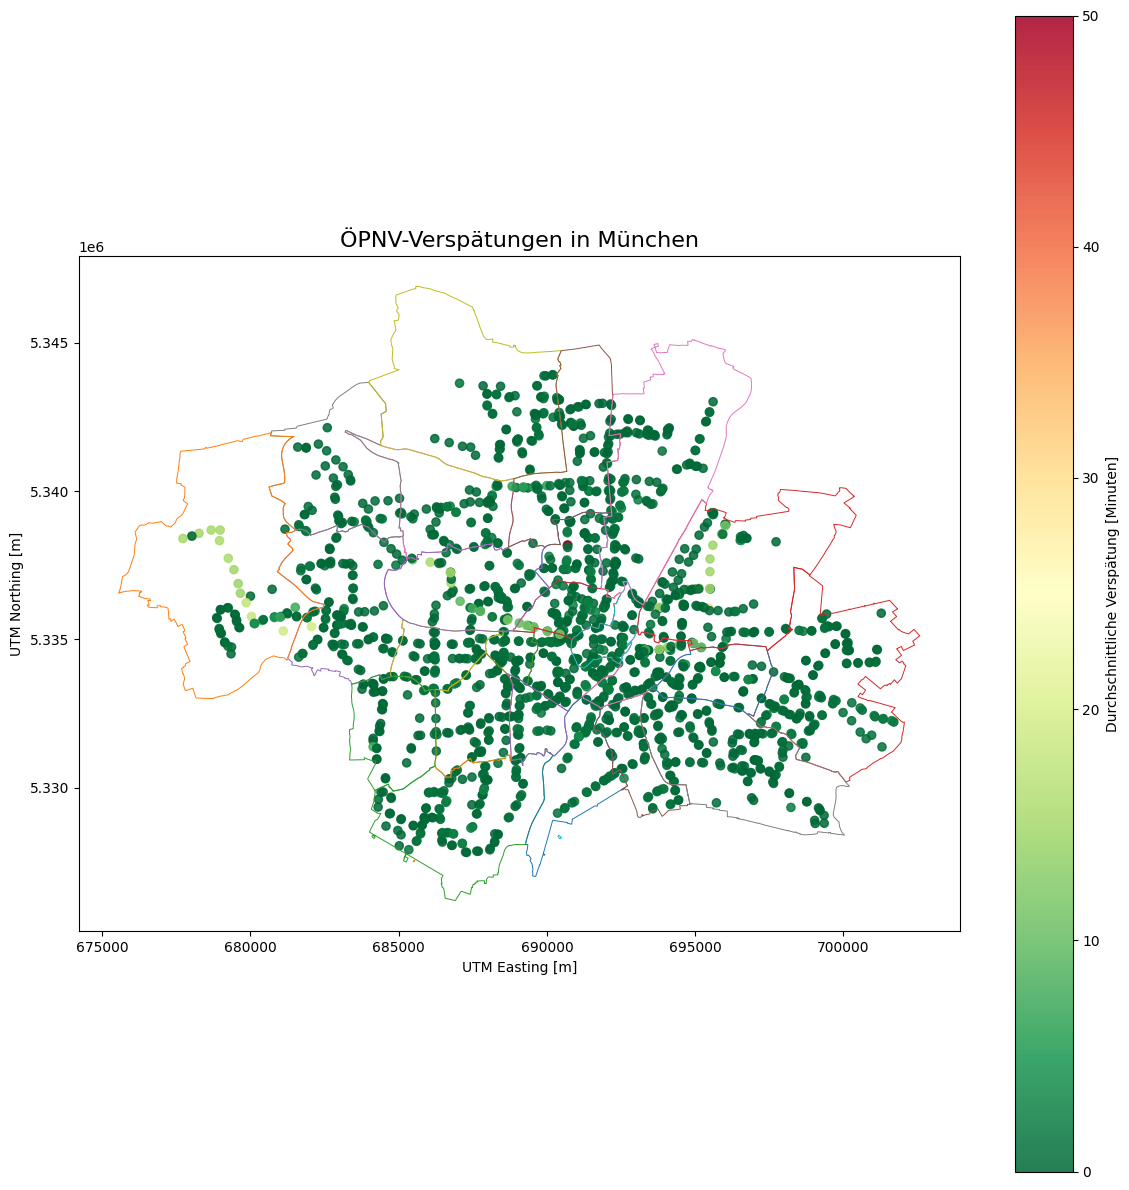

In [45]:
def plot_munich_boundaries(ax, munich_geojson):
    """
    Plot the Munich administrative boundaries on a Matplotlib axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Matplotlib axis on which the boundaries are plotted.

    munich_geojson : dict
        GeoJSON data containing the boundaries of Munich.
    """

    for geojson_feature in munich_geojson["features"]:

        geometry = geojson_feature["geometry"]
        geometry_type = geometry["type"]

        if geometry_type == "Polygon":
            polygons = [geometry["coordinates"]]

        elif geometry_type == "MultiPolygon":
            polygons = geometry["coordinates"]

        else:
            continue

        for polygon in polygons:

            for polygon_ring in polygon:

                x_coordinates = [
                    coordinate[0]
                    for coordinate in polygon_ring
                ]

                y_coordinates = [
                    coordinate[1]
                    for coordinate in polygon_ring
                ]

                ax.plot(
                    x_coordinates,
                    y_coordinates,
                    linewidth=0.7
                )


def plot_station_delays(ax, station_delay_df):
    """
    Plot average station delays as a colored scatter plot.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Matplotlib axis on which the stations are plotted.

    station_delay_df : pandas.DataFrame
        DataFrame containing UTM coordinates and average delays.
        Must contain ``utm_x``, ``utm_y`` and ``delay_minutes`` columns.

    Returns
    -------
    matplotlib.collections.PathCollection
        Scatter plot object used for creating the colorbar.
    """

    scatter = ax.scatter(
        station_delay_df["utm_x"],
        station_delay_df["utm_y"],
        c=station_delay_df["delay_minutes"],
        cmap="RdYlGn_r",
        s=35,
        alpha=0.85
    )

    return scatter


def configure_munich_delay_plot(ax):
    """
    Configure the title, axis labels, and aspect ratio of the plot.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Matplotlib axis to configure.
    """

    ax.set_title(
        "ÖPNV-Verspätungen in München",
        fontsize=16
    )

    ax.set_xlabel(
        "UTM Easting [m]"
    )

    ax.set_ylabel(
        "UTM Northing [m]"
    )

    ax.set_aspect("equal")


def plot_munich_station_delays(
    station_delay_df,
    munich_geojson,
    output_path="../docs/munich_delays.png"
):
    """
    Create and save a map of average public transport delays in Munich.

    Parameters
    ----------
    station_delay_df : pandas.DataFrame
        DataFrame containing station coordinates and average delays.
        Must contain ``utm_x``, ``utm_y`` and ``delay_minutes`` columns.

    munich_geojson : dict
        GeoJSON data containing the boundaries of Munich.

    output_path : str
        Path where the generated plot will be saved.

    Returns
    -------
    None
        The plot is saved to the specified output path and displayed.
    """

    station_delay_df = filter_stations_inside_munich(
        station_delay_df,
        munich_geojson
    )

    figure, axis = plt.subplots(
        figsize=(12, 12)
    )

    plot_munich_boundaries(
        axis,
        munich_geojson
    )

    scatter = plot_station_delays(
        axis,
        station_delay_df
    )

    colorbar = figure.colorbar(
        scatter,
        ax=axis
    )

    colorbar.set_label(
        "Durchschnittliche Verspätung [Minuten]"
    )

    configure_munich_delay_plot(axis)

    figure.tight_layout()

    figure.savefig(
        output_path,
        dpi=70,
        bbox_inches="tight"
    )

    plt.show()

    
plot_munich_station_delays(
    station_delay,
    munich_map
)
